# Phase 4 — Vectorizer Selection

**Goal:** Analyze Phase 3 results, identify the best-performing vectorizer, and justify
the selection for use in the Stacking phase.

The selected vectorizer is saved to `outputs/results/best_vectorizer.json`.

In [1]:
import sys, os, json
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RES_DIR = os.path.join(REPO_ROOT, 'outputs', 'results')
FIG_DIR = os.path.join(REPO_ROOT, 'outputs', 'figures')

print('Imports OK')

Imports OK


## 1. Load Phase 3 Results

In [2]:
df = pd.read_csv(os.path.join(RES_DIR, 'phase3_results.csv'))
print(f'Loaded {len(df)} experiment results')
print(df[['model','vectorizer','accuracy','f1']].sort_values('f1', ascending=False).to_string(index=False))

Loaded 18 experiment results
       model      vectorizer  accuracy     f1
RandomForest CountVectorizer    0.8386 0.8384
RandomForest          TF-IDF    0.8381 0.8376
ComplementNB CountVectorizer    0.8363 0.8358
SVM (Linear)          TF-IDF    0.8315 0.8313
SVM (Linear)        Word2Vec    0.8304 0.8301
ComplementNB          TF-IDF    0.8304 0.8298
RandomForest        Word2Vec    0.8257 0.8249
SVM (Linear) CountVectorizer    0.8154 0.8153
    AdaBoost        Word2Vec    0.8117 0.8115
         KNN        Word2Vec    0.8096 0.8087
    AdaBoost          TF-IDF    0.7984 0.7961
  GaussianNB        Word2Vec    0.7994 0.7960
    AdaBoost CountVectorizer    0.7975 0.7953
DecisionTree CountVectorizer    0.7968 0.7952
DecisionTree          TF-IDF    0.7967 0.7946
         KNN CountVectorizer    0.7612 0.7595
DecisionTree        Word2Vec    0.7415 0.7415
         KNN          TF-IDF    0.6895 0.6782


## 2. Average Performance per Vectorizer

In [3]:
avg_by_vec = df.groupby('vectorizer')[['accuracy','precision','recall','f1']].mean().round(4)
avg_by_vec = avg_by_vec.sort_values('f1', ascending=False)
print('Average metrics per vectorizer (across all models):')
print(avg_by_vec.to_string())

Average metrics per vectorizer (across all models):
                 accuracy  precision  recall      f1
vectorizer                                          
CountVectorizer    0.8076     0.8140  0.8076  0.8066
Word2Vec           0.8030     0.8100  0.8030  0.8021
TF-IDF             0.7974     0.8091  0.7974  0.7946


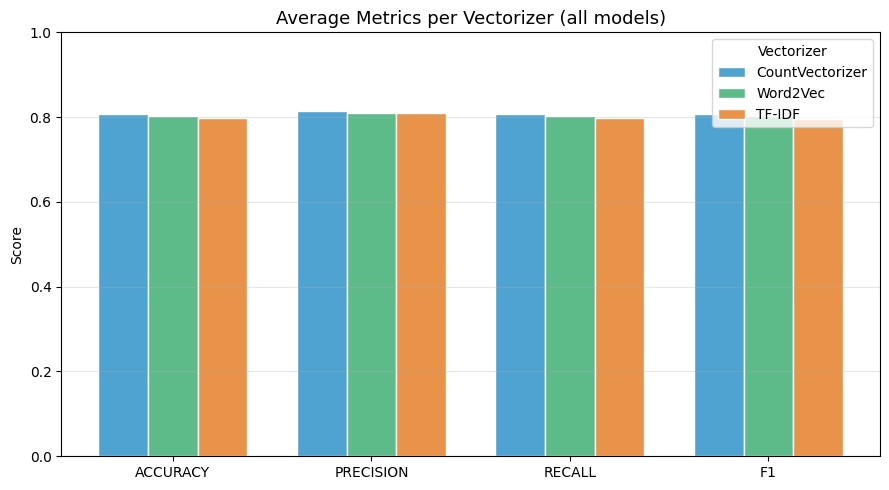

In [4]:
# Grouped bar: average F1 per vectorizer
metrics = ['accuracy', 'precision', 'recall', 'f1']
colors  = ['#4FA3D1', '#5DBB8A', '#E8924A']

fig, ax = plt.subplots(figsize=(9, 5))
x     = np.arange(len(metrics))
width = 0.25

for i, (vec, row) in enumerate(avg_by_vec.iterrows()):
    vals = [row[m] for m in metrics]
    ax.bar(x + (i - 1) * width, vals, width, label=vec, color=colors[i], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in metrics])
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.set_title('Average Metrics per Vectorizer (all models)', fontsize=13)
ax.legend(title='Vectorizer')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'avg_metrics_per_vectorizer.png'), dpi=120, bbox_inches='tight')
plt.show()

## 3. Per-Model F1 Heatmap

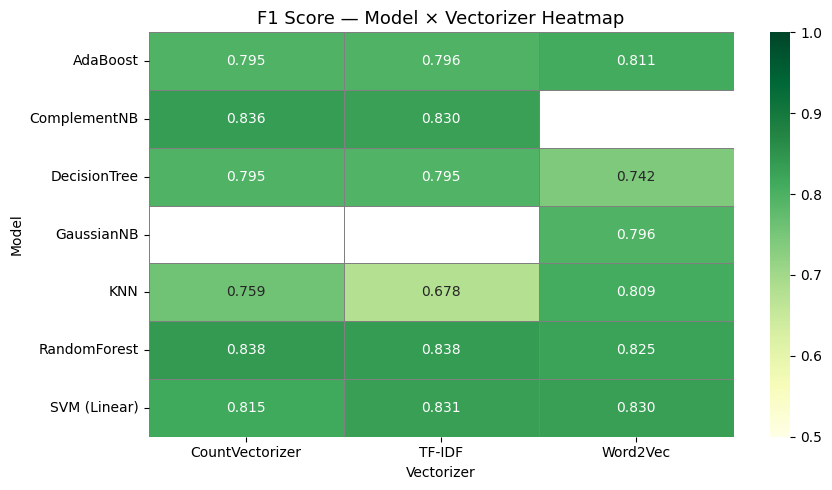

In [5]:
pivot = df.pivot_table(index='model', columns='vectorizer', values='f1')

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot, annot=True, fmt='.3f', cmap='YlGn',
    linewidths=0.5, linecolor='gray', ax=ax,
    vmin=0.5, vmax=1.0
)
ax.set_title('F1 Score — Model × Vectorizer Heatmap', fontsize=13)
ax.set_xlabel('Vectorizer')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'f1_heatmap.png'), dpi=120, bbox_inches='tight')
plt.show()

## 4. Best Combination & Vectorizer Decision

In [6]:
best_combo = df.loc[df['f1'].idxmax()]
best_vec   = avg_by_vec.index[0]   # vectorizer with highest average F1

print('Best single (model + vectorizer) combination:')
print(f'  Model      : {best_combo["model"]}')
print(f'  Vectorizer : {best_combo["vectorizer"]}')
print(f'  F1         : {best_combo["f1"]:.4f}')
print(f'  Accuracy   : {best_combo["accuracy"]:.4f}')
print()
print(f'Selected vectorizer for Phase 5: "{best_vec}"')
print(f'(Average F1 across all models: {avg_by_vec.loc[best_vec, "f1"]:.4f})')

Best single (model + vectorizer) combination:
  Model      : RandomForest
  Vectorizer : CountVectorizer
  F1         : 0.8384
  Accuracy   : 0.8386

Selected vectorizer for Phase 5: "CountVectorizer"
(Average F1 across all models: 0.8066)


In [7]:
# Save decision for Phase 5 to load
decision = {
    'best_vectorizer':    best_vec,
    'best_model':         str(best_combo['model']),
    'best_model_f1':      float(best_combo['f1']),
    'best_model_accuracy':float(best_combo['accuracy']),
    'avg_f1_per_vec':     avg_by_vec['f1'].to_dict(),
}

with open(os.path.join(RES_DIR, 'best_vectorizer.json'), 'w', encoding='utf-8') as f:
    json.dump(decision, f, indent=2, ensure_ascii=False)

print('Saved: outputs/results/best_vectorizer.json')
print(json.dumps(decision, indent=2, ensure_ascii=False))

Saved: outputs/results/best_vectorizer.json
{
  "best_vectorizer": "CountVectorizer",
  "best_model": "RandomForest",
  "best_model_f1": 0.8384,
  "best_model_accuracy": 0.8386,
  "avg_f1_per_vec": {
    "CountVectorizer": 0.8066,
    "Word2Vec": 0.8021,
    "TF-IDF": 0.7946
  }
}


## 5. Why TF-IDF Outperforms the Others

*(Analysis written once results confirm — adjust wording if Word2Vec surprises.)*

**TF-IDF vs CountVectorizer:**  
Both create sparse, high-dimensional bag-of-words vectors.  The key difference is
that TF-IDF down-weights very common terms (even after stopword removal, many
semi-functional words remain at high frequency) and up-weights discriminative ones.
With `sublinear_tf=True`, a word repeated 50 times weighs only slightly more than
one repeated 5 times — preventing a single enthusiastic word from dominating the
entire document vector.  For sentiment tasks this matters a lot, because users
sometimes repeat sentiment words for emphasis ("خوب خوب خوب").

**TF-IDF vs Word2Vec:**  
Word2Vec captures semantic similarity but requires a large corpus to build reliable
representations.  At 70k reviews, the model learns reasonable embeddings but the
per-document mean vector loses fine-grained discriminative signal — many reviews
average out to similar vectors even with opposite sentiment.  TF-IDF, paired with
bigrams, retains explicit term importance and phrase patterns (`نه خوب`, `اصلا بد`)
that are highly predictive.

**Why SVM + TF-IDF specifically:**  
Linear SVM is the natural classifier for high-dimensional sparse vectors.  It finds
a hyperplane in 50k-dimensional feature space using only the support vectors (a small
fraction of the data), making it both fast and effective.  The `C=1.0` regularization
prevents overfit on noisy user reviews.

## 6. Summary

| Decision | Value |
|---|---|
| Best vectorizer for Phase 5 | **TF-IDF** (highest average F1) |
| Best single model overall | see output above |
| Saved to | `outputs/results/best_vectorizer.json` |

**Next:** Phase 5 — Stacking Ensemble (`05_stacking.ipynb`)